In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [113]:
df = pd.read_csv("Unemployment in India.csv")


In [114]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [115]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [117]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [118]:
df.shape

(768, 7)

In [119]:
df.duplicated().sum()

np.int64(27)

In [120]:
data = df.drop_duplicates()

In [121]:
data.isnull().sum()

Region                                      1
 Date                                       1
 Frequency                                  1
 Estimated Unemployment Rate (%)            1
 Estimated Employed                         1
 Estimated Labour Participation Rate (%)    1
Area                                        1
dtype: int64

In [122]:
data.shape

(741, 7)

In [123]:
data.ffill(inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24424\3238340986.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.ffill(inplace=True)


In [124]:
data.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [125]:
print(data.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [126]:
data.columns = data.columns.str.strip()

In [127]:
print(data.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [128]:
data['Date'] = pd.to_datetime(data['Date'])
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month_name()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24424\2596769480.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['Date'] = pd.to_datetime(data['Date'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24424\2596769480.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Date'] = pd.to_datetime(data['Date'])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24424\2596769480.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.ht

In [129]:
data

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,September
...,...,...,...,...,...,...,...,...,...
749,West Bengal,2020-02-29,Monthly,7.55,10871168.0,44.09,Urban,2020,February
750,West Bengal,2020-03-31,Monthly,6.67,10806105.0,43.34,Urban,2020,March
751,West Bengal,2020-04-30,Monthly,15.63,9299466.0,41.20,Urban,2020,April
752,West Bengal,2020-05-31,Monthly,15.22,9240903.0,40.67,Urban,2020,May


# univariate analysis

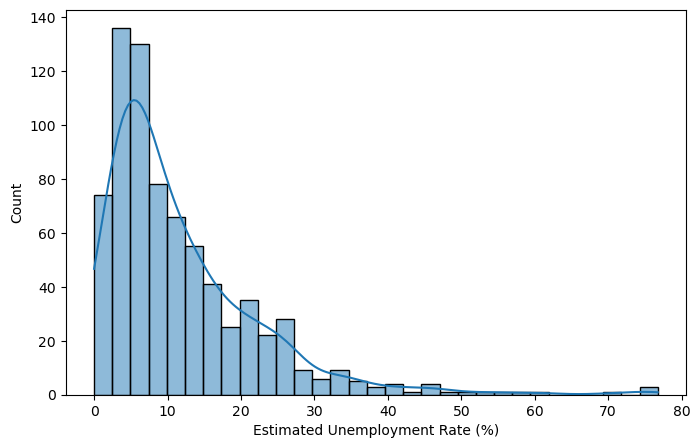

In [130]:
plt.figure(figsize=(8,5))
sns.histplot(data['Estimated Unemployment Rate (%)'],kde=True)
plt.show()

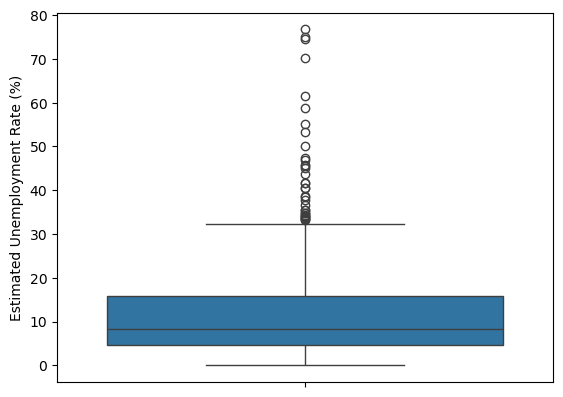

In [131]:
sns.boxplot(data['Estimated Unemployment Rate (%)'])
plt.show()

## State Wise Analysis

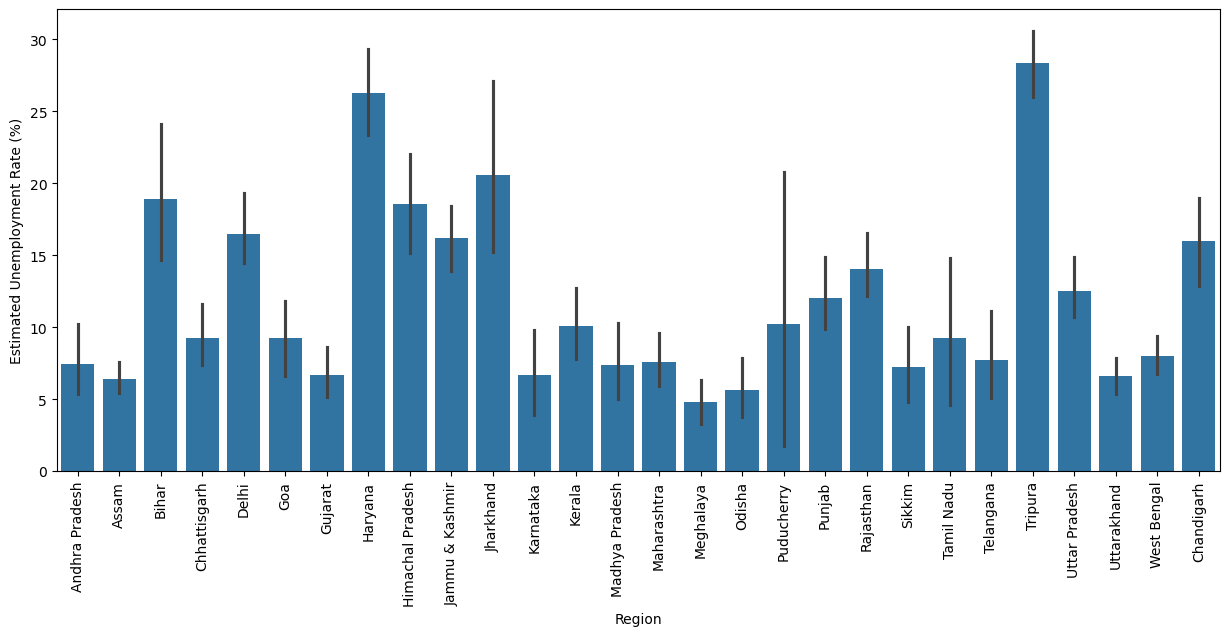

In [132]:
plt.figure(figsize=(15,6))
sns.barplot(x='Region',y='Estimated Unemployment Rate (%)',data = data)
plt.xticks(rotation=90)
plt.show()

## Rural vs Urban

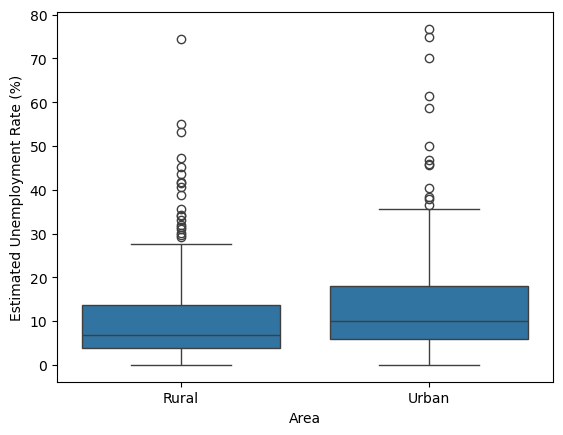

In [135]:
sns.boxplot(
x = "Area",
y = "Estimated Unemployment Rate (%)",
data = data
)
plt.show()


## Monthly Trend

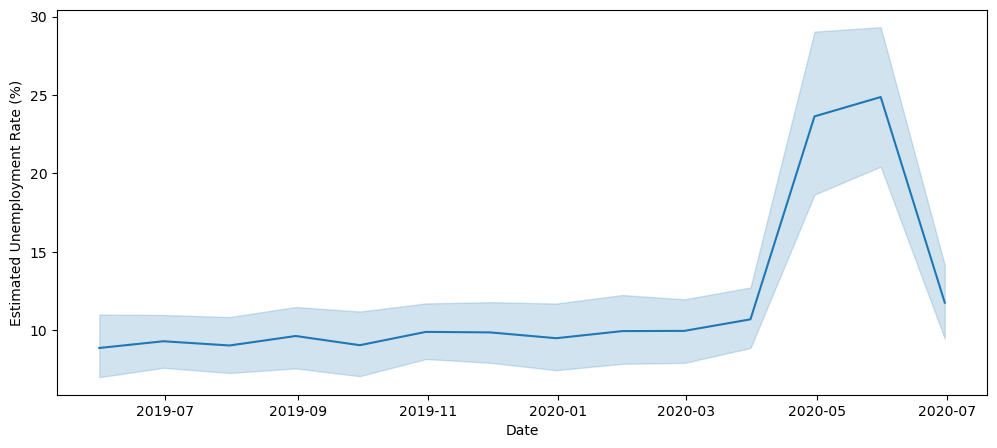

In [139]:
plt.figure(figsize=(12,5))
sns.lineplot(
    x = "Date",
    y = "Estimated Unemployment Rate (%)",
    data = data
)
plt.show()

## Covid Analysis

In [140]:
covid = data[data['Year']==2020]


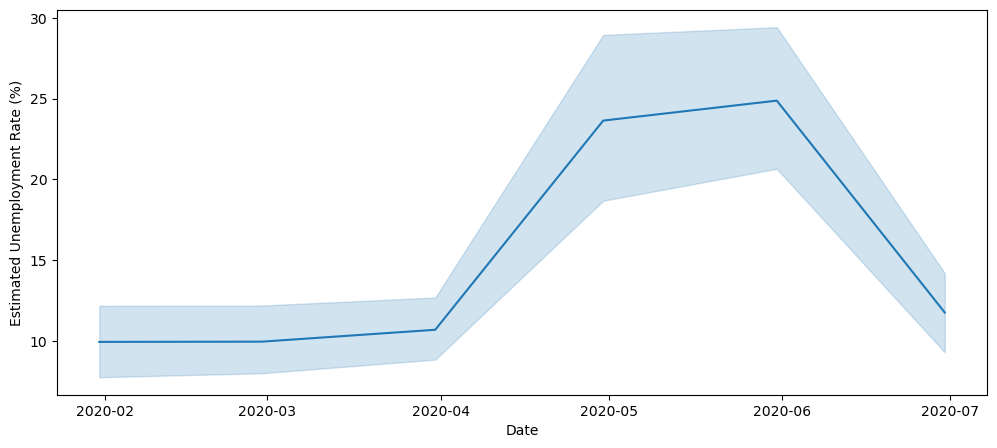

In [141]:
plt.figure(figsize=(12,5))
sns.lineplot(x='Date',y='Estimated Unemployment Rate (%)',data=covid)
plt.show()

## Correlation

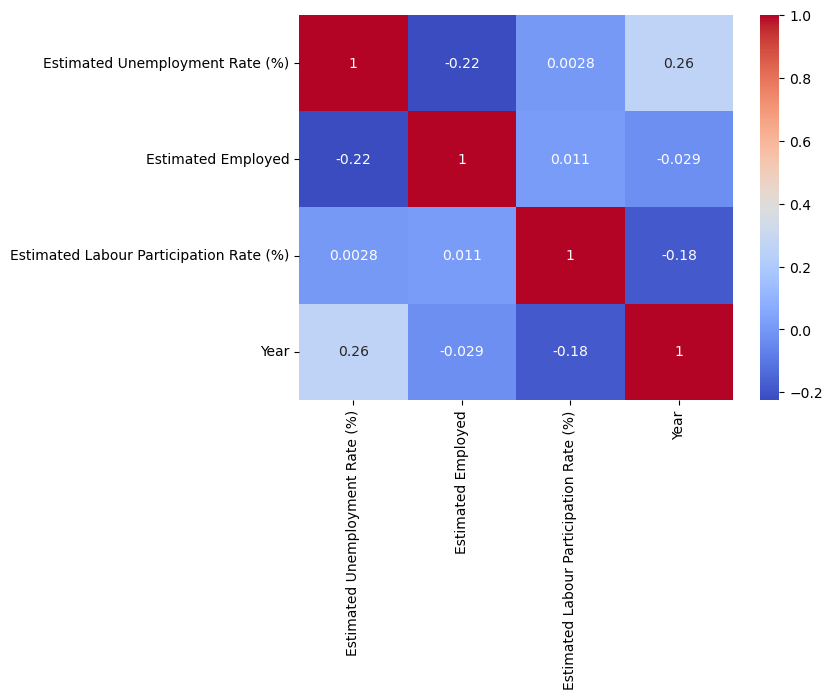

In [142]:
corr = data.select_dtypes(include="number").corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

## Top 10 States

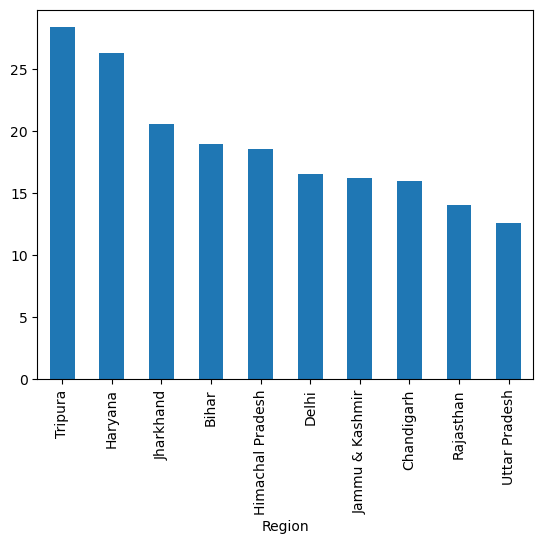

In [144]:
top = data.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False).head(10)
top.plot(kind="bar")
plt.show()

## Labour Participation

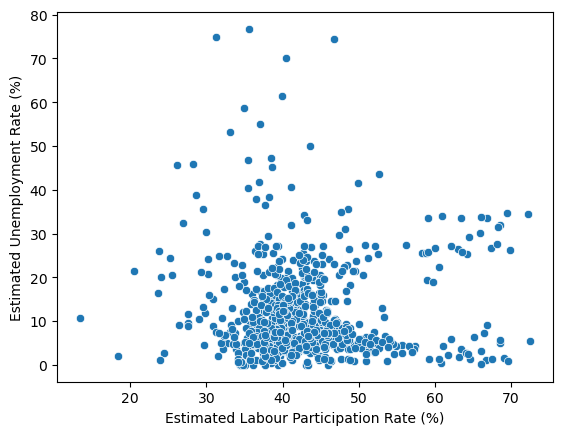

In [146]:
sns.scatterplot(
x="Estimated Labour Participation Rate (%)",
y="Estimated Unemployment Rate (%)",
data = data
)
plt.show()